# 03 — Revenue Leakage

Explores the output of `src/revenue_leakage/leakage_engine.py`: six
non-overlapping leakage mechanisms, each with a recovery status. See
`README.md` section 13 for the full methodology and why two of the six
types are advisory-only (excluded from the realized leakage total).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
COLOR_PRIMARY = "#2A5CA6"
COLOR_RISK = "#C0392B"
COLOR_WARN = "#D68910"
COLOR_OK = "#2E8B57"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
leakage = pd.read_csv(PROCESSED / "revenue_leakage.csv")
ADVISORY = ["Rate Discrepancy", "Refund Fee Retention (Policy Review)"]
realized = leakage[~leakage["leakage_type"].isin(ADVISORY)]
print(f"Total leakage rows: {len(leakage):,} | Realized: {len(realized):,} | Advisory: {len(leakage) - len(realized):,}")
print(f"Total realized leakage: {realized['leakage_amount'].sum():,.2f}")

Total leakage rows: 24,684 | Realized: 1,872 | Advisory: 22,812
Total realized leakage: 756,317.91


## Realized leakage by type

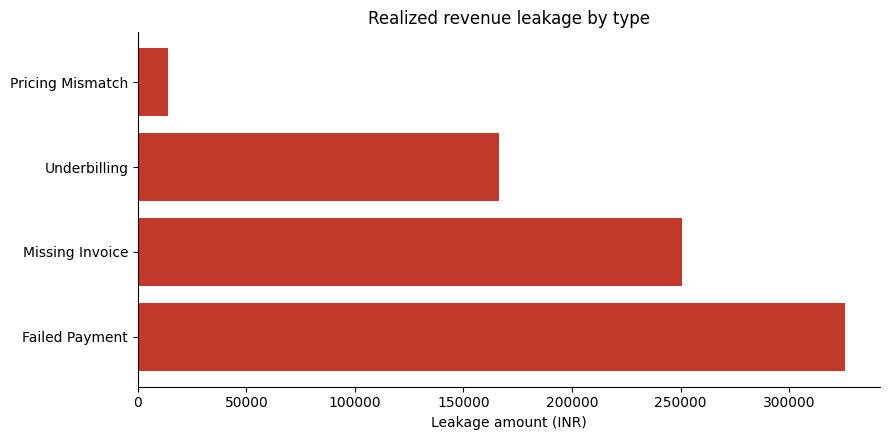

,leakage_amount
leakage_type,
Failed Payment,"325,644.12"
Missing Invoice,"250,735.82"
Underbilling,"166,137.98"
Pricing Mismatch,"13,799.99"


In [3]:
by_type = realized.groupby("leakage_type")["leakage_amount"].sum().sort_values(ascending=False)
fig, ax = plt.subplots()
ax.barh(by_type.index, by_type.values, color=COLOR_RISK)
ax.set_xlabel("Leakage amount (INR)")
ax.set_title("Realized revenue leakage by type")
plt.tight_layout()
plt.show()
by_type.to_frame("leakage_amount")

## Leakage by recovery status

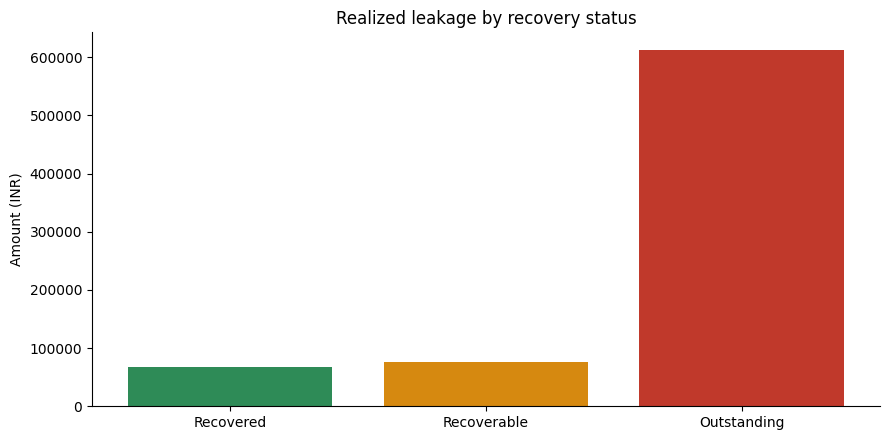

,leakage_amount
status,
Recovered,"67,834.30"
Recoverable,"76,433.63"
Outstanding,"612,049.98"


In [4]:
by_status = realized.groupby("status")["leakage_amount"].sum().reindex(["Recovered", "Recoverable", "Outstanding"])
fig, ax = plt.subplots()
status_colors = {"Recovered": COLOR_OK, "Recoverable": COLOR_WARN, "Outstanding": COLOR_RISK}
ax.bar(by_status.index, by_status.values, color=[status_colors[s] for s in by_status.index])
ax.set_ylabel("Amount (INR)")
ax.set_title("Realized leakage by recovery status")
plt.tight_layout()
plt.show()
by_status.to_frame("leakage_amount")

## Top 10 merchants by leakage exposure

In [5]:
top_merchants = realized.groupby("merchant_id")["leakage_amount"].sum().sort_values(ascending=False).head(10)
top_merchants.to_frame("leakage_amount")

,leakage_amount
merchant_id,
MER00083,"18,643.66"
MER00839,"16,670.43"
MER00319,"14,948.36"
MER00016,"13,816.89"
MER00792,"13,173.81"
MER00751,"11,807.65"
MER00344,"9,806.07"
MER00819,"9,314.28"
MER00181,"8,269.53"


## Severity distribution

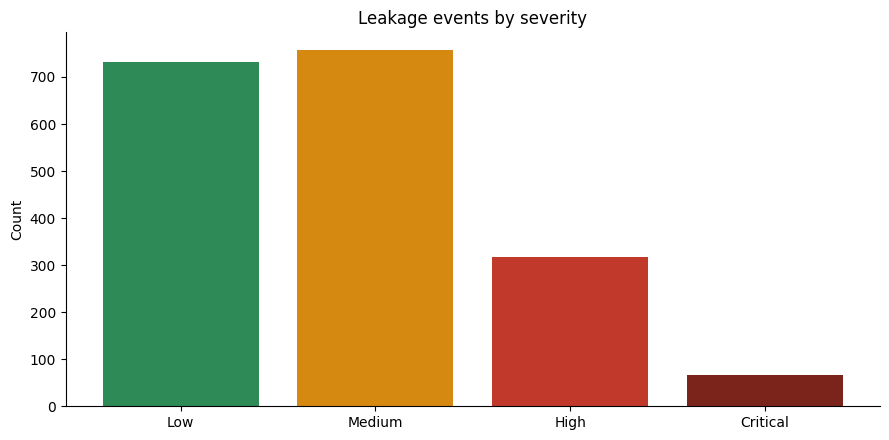

In [6]:
sev_order = ["Low", "Medium", "High", "Critical"]
sev_counts = realized["severity"].value_counts().reindex(sev_order)
fig, ax = plt.subplots()
ax.bar(sev_counts.index, sev_counts.values, color=["#2E8B57", "#D68910", "#C0392B", "#7B241C"])
ax.set_ylabel("Count")
ax.set_title("Leakage events by severity")
plt.tight_layout()
plt.show()

## Takeaways

- Failed Payment is now the largest realized leakage category — see
  `docs/business_insights.md` insight #2 for why it needs its own recovery
  workflow rather than the standard overdue-invoice treatment.
- 81% of realized leakage is still `Outstanding` — most of the recovery
  opportunity here hasn't been acted on yet.